# Notebook 03 — Agents & Training

## Projet : C-MARL pour la réduction des absences aux rendez-vous médicaux

Ce notebook réalise l'étape principale du projet :

- charger les datasets préparés par le Notebook 01 ;
- réutiliser l'environnement RL du Notebook 02 ;
- créer un agent Q-learning simple ;
- entraîner séparément les stages Easy, Medium et Hard ;
- sauvegarder les checkpoints ;
- sauvegarder les rewards pour l'évaluation.

> Remarque : pour rester facile à réaliser, le C-MARL est simulé avec une récompense coopérative commune. Les décisions correspondent à la coopération entre les agents fonctionnels : Risk Agent, Reminder Agent et Scheduling Agent.

In [1]:
import os
import pickle
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Cellule 2 — Chemins du projet

Le notebook doit être placé dans :

`medical_c_marl_project/notebooks/`

Les fichiers préparés doivent exister dans :

`medical_c_marl_project/results/`

In [2]:
PROJECT_PATH = os.path.abspath("..")

RESULTS_DIR = os.path.join(PROJECT_PATH, "results")
CHECKPOINT_DIR = os.path.join(PROJECT_PATH, "checkpoints")

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

EASY_PATH = os.path.join(RESULTS_DIR, "easy_data.csv")
MEDIUM_PATH = os.path.join(RESULTS_DIR, "medium_data.csv")
HARD_PATH = os.path.join(RESULTS_DIR, "hard_data.csv")

print("Project path:", PROJECT_PATH)
print("Results dir:", RESULTS_DIR)
print("Checkpoint dir:", CHECKPOINT_DIR)

Project path: C:\Users\UltraPc\Documents\ML PROBA\C-marl
Results dir: C:\Users\UltraPc\Documents\ML PROBA\C-marl\results
Checkpoint dir: C:\Users\UltraPc\Documents\ML PROBA\C-marl\checkpoints


## Cellule 3 — Charger les datasets Easy, Medium et Hard

In [3]:
easy_data = pd.read_csv(EASY_PATH)
medium_data = pd.read_csv(MEDIUM_PATH)
hard_data = pd.read_csv(HARD_PATH)

print("Easy data:", easy_data.shape)
print("Medium data:", medium_data.shape)
print("Hard data:", hard_data.shape)

easy_data.head()

Easy data: (110521, 4)
Medium data: (110521, 10)
Hard data: (110521, 13)


,AgeGroup,Gender,SMS_received,No_show
0,3,0,0,0
1,2,1,0,0
2,3,0,0,0
3,0,0,0,0
4,2,0,0,0


## Cellule 4 — Définir l'environnement RL

Même logique que dans le Notebook 02 :

- `state` = informations du patient sans `No_show`;
- `action` = décision du système;
- `reward` = score selon la qualité de la décision;
- `done` = fin de l'épisode.

In [4]:
class MedicalAppointmentEnv:
    def __init__(self, data, stage, max_steps=None, shuffle=True):
        self.data_original = data.reset_index(drop=True)
        self.stage = stage
        self.max_steps = max_steps
        self.shuffle = shuffle
        self.current_index = 0

        if stage == "easy":
            self.actions = [0, 1]
        elif stage == "medium":
            self.actions = [0, 1, 2]
        elif stage == "hard":
            self.actions = [0, 1, 2, 3]
        else:
            raise ValueError("stage must be: easy, medium, or hard")

        self.n_actions = len(self.actions)
        self.data = self.data_original.copy()

    def reset(self):
        if self.shuffle:
            self.data = self.data_original.sample(frac=1).reset_index(drop=True)
        else:
            self.data = self.data_original.copy()

        if self.max_steps is not None:
            self.data = self.data.iloc[:self.max_steps].reset_index(drop=True)

        self.current_index = 0
        return self._get_state()

    def _get_state(self):
        if self.current_index >= len(self.data):
            return None

        patient = self.data.iloc[self.current_index]
        state = patient.drop("No_show").values
        return tuple(state.astype(int))

    def step(self, action):
        patient = self.data.iloc[self.current_index]
        reward = self._calculate_reward(patient, action)

        self.current_index += 1
        done = self.current_index >= len(self.data)
        next_state = None if done else self._get_state()

        return next_state, reward, done

    def _calculate_reward(self, patient, action):
        no_show = int(patient["No_show"])
        reward = 0

        if self.stage == "easy":
            if no_show == 1 and action == 1:
                reward += 2
            elif no_show == 1 and action == 0:
                reward -= 2
            elif no_show == 0 and action == 0:
                reward += 1
            elif no_show == 0 and action == 1:
                reward -= 0.5

        elif self.stage == "medium":
            medical_risk = int(patient["MedicalRisk"])

            if no_show == 1 and action == 1:
                reward += 3
            elif medical_risk == 1 and action == 2:
                reward += 2
            elif no_show == 1 and action == 0:
                reward -= 3
            elif no_show == 0 and action == 0:
                reward += 1
            else:
                reward -= 1

        elif self.stage == "hard":
            medical_risk = int(patient["MedicalRisk"])
            waiting_group = int(patient["WaitingGroup"])

            if no_show == 1 and action in [1, 3]:
                reward += 5
            elif no_show == 1 and action == 0:
                reward -= 5
            elif medical_risk == 1 and action == 2:
                reward += 3
            elif waiting_group >= 2 and action == 3:
                reward += 3
            elif no_show == 0 and action == 0:
                reward += 2
            else:
                reward -= 2

        return reward

    def get_action_space(self):
        return self.n_actions

    def get_number_of_patients(self):
        return len(self.data)

## Cellule 5 — Créer l'agent Q-learning

Le Q-learning utilise une table appelée `Q-table`.

La Q-table garde une valeur pour chaque couple :

`(state, action)`

L'agent choisit soit :

- une action aléatoire pour explorer ;
- la meilleure action connue pour exploiter l'apprentissage.

In [5]:
class QLearningAgent:
    def __init__(self, n_actions, learning_rate=0.1, gamma=0.95, epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.05):
        self.n_actions = n_actions
        self.lr = learning_rate
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.q_table = {}

    def _init_state(self, state):
        if state not in self.q_table:
            self.q_table[state] = np.zeros(self.n_actions)

    def choose_action(self, state):
        self._init_state(state)

        if random.random() < self.epsilon:
            return random.randint(0, self.n_actions - 1)
        else:
            return int(np.argmax(self.q_table[state]))

    def update(self, state, action, reward, next_state, done):
        self._init_state(state)

        current_q = self.q_table[state][action]

        if done or next_state is None:
            target_q = reward
        else:
            self._init_state(next_state)
            target_q = reward + self.gamma * np.max(self.q_table[next_state])

        self.q_table[state][action] = current_q + self.lr * (target_q - current_q)

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

## Cellule 6 — Fonction d'entraînement

Pour rendre l'entraînement rapide dans Jupyter, on utilise `max_steps`.

Tu peux commencer avec :

- `episodes = 30`
- `max_steps = 5000`

Ensuite, si tout fonctionne, tu peux augmenter.

In [6]:
def train_stage(stage_name, data, episodes=30, max_steps=5000):
    env = MedicalAppointmentEnv(data=data, stage=stage_name, max_steps=max_steps, shuffle=True)
    agent = QLearningAgent(
        n_actions=env.get_action_space(),
        learning_rate=0.1,
        gamma=0.95,
        epsilon=1.0,
        epsilon_decay=0.97,
        epsilon_min=0.05
    )

    rewards_history = []
    average_rewards = []

    for episode in range(1, episodes + 1):
        state = env.reset()
        done = False
        total_reward = 0
        steps = 0

        while not done:
            action = agent.choose_action(state)
            next_state, reward, done = env.step(action)
            agent.update(state, action, reward, next_state, done)

            state = next_state
            total_reward += reward
            steps += 1

        agent.decay_epsilon()

        avg_reward = total_reward / steps if steps > 0 else 0
        rewards_history.append(total_reward)
        average_rewards.append(avg_reward)

        print(
            f"Stage: {stage_name.upper()} | "
            f"Episode {episode}/{episodes} | "
            f"Total Reward: {total_reward:.2f} | "
            f"Average Reward: {avg_reward:.4f} | "
            f"Epsilon: {agent.epsilon:.4f}"
        )

    history = pd.DataFrame({
        "episode": range(1, episodes + 1),
        "total_reward": rewards_history,
        "average_reward": average_rewards
    })

    return agent, history

## Cellule 7 — Entraîner le Stage Easy

In [7]:
easy_agent, easy_history = train_stage(
    stage_name="easy",
    data=easy_data,
    episodes=30,
    max_steps=5000
)

easy_history.head()

Stage: EASY | Episode 1/30 | Total Reward: 943.50 | Average Reward: 0.1887 | Epsilon: 0.9700
Stage: EASY | Episode 2/30 | Total Reward: 1157.50 | Average Reward: 0.2315 | Epsilon: 0.9409
Stage: EASY | Episode 3/30 | Total Reward: 1032.50 | Average Reward: 0.2065 | Epsilon: 0.9127
Stage: EASY | Episode 4/30 | Total Reward: 1179.00 | Average Reward: 0.2358 | Epsilon: 0.8853
Stage: EASY | Episode 5/30 | Total Reward: 992.00 | Average Reward: 0.1984 | Epsilon: 0.8587
Stage: EASY | Episode 6/30 | Total Reward: 1189.00 | Average Reward: 0.2378 | Epsilon: 0.8330
Stage: EASY | Episode 7/30 | Total Reward: 1195.50 | Average Reward: 0.2391 | Epsilon: 0.8080
Stage: EASY | Episode 8/30 | Total Reward: 1133.50 | Average Reward: 0.2267 | Epsilon: 0.7837
Stage: EASY | Episode 9/30 | Total Reward: 1210.00 | Average Reward: 0.2420 | Epsilon: 0.7602
Stage: EASY | Episode 10/30 | Total Reward: 1300.50 | Average Reward: 0.2601 | Epsilon: 0.7374
Stage: EASY | Episode 11/30 | Total Reward: 1224.50 | Average

,episode,total_reward,average_reward
0,1,943.5,0.1887
1,2,1157.5,0.2315
2,3,1032.5,0.2065
3,4,1179.0,0.2358
4,5,992.0,0.1984


## Cellule 8 — Sauvegarder le checkpoint Easy

In [8]:
easy_checkpoint_path = os.path.join(CHECKPOINT_DIR, "checkpoint_easy.pkl")
easy_rewards_path = os.path.join(RESULTS_DIR, "rewards_easy.csv")

with open(easy_checkpoint_path, "wb") as f:
    pickle.dump(easy_agent, f)

easy_history.to_csv(easy_rewards_path, index=False)

print("Checkpoint Easy sauvegardé:", easy_checkpoint_path)
print("Rewards Easy sauvegardées:", easy_rewards_path)

Checkpoint Easy sauvegardé: C:\Users\UltraPc\Documents\ML PROBA\C-marl\checkpoints\checkpoint_easy.pkl
Rewards Easy sauvegardées: C:\Users\UltraPc\Documents\ML PROBA\C-marl\results\rewards_easy.csv


## Cellule 9 — Entraîner le Stage Medium

In [9]:
medium_agent, medium_history = train_stage(
    stage_name="medium",
    data=medium_data,
    episodes=30,
    max_steps=5000
)

medium_history.head()

Stage: MEDIUM | Episode 1/30 | Total Reward: -352.00 | Average Reward: -0.0704 | Epsilon: 0.9700
Stage: MEDIUM | Episode 2/30 | Total Reward: -295.00 | Average Reward: -0.0590 | Epsilon: 0.9409
Stage: MEDIUM | Episode 3/30 | Total Reward: -399.00 | Average Reward: -0.0798 | Epsilon: 0.9127
Stage: MEDIUM | Episode 4/30 | Total Reward: -218.00 | Average Reward: -0.0436 | Epsilon: 0.8853
Stage: MEDIUM | Episode 5/30 | Total Reward: -130.00 | Average Reward: -0.0260 | Epsilon: 0.8587
Stage: MEDIUM | Episode 6/30 | Total Reward: 5.00 | Average Reward: 0.0010 | Epsilon: 0.8330
Stage: MEDIUM | Episode 7/30 | Total Reward: 188.00 | Average Reward: 0.0376 | Epsilon: 0.8080
Stage: MEDIUM | Episode 8/30 | Total Reward: 97.00 | Average Reward: 0.0194 | Epsilon: 0.7837
Stage: MEDIUM | Episode 9/30 | Total Reward: 267.00 | Average Reward: 0.0534 | Epsilon: 0.7602
Stage: MEDIUM | Episode 10/30 | Total Reward: 469.00 | Average Reward: 0.0938 | Epsilon: 0.7374
Stage: MEDIUM | Episode 11/30 | Total Rewa

,episode,total_reward,average_reward
0,1,-352,-0.0704
1,2,-295,-0.0590
2,3,-399,-0.0798
3,4,-218,-0.0436
4,5,-130,-0.0260


## Cellule 10 — Sauvegarder le checkpoint Medium

In [10]:
medium_checkpoint_path = os.path.join(CHECKPOINT_DIR, "checkpoint_medium.pkl")
medium_rewards_path = os.path.join(RESULTS_DIR, "rewards_medium.csv")

with open(medium_checkpoint_path, "wb") as f:
    pickle.dump(medium_agent, f)

medium_history.to_csv(medium_rewards_path, index=False)

print("Checkpoint Medium sauvegardé:", medium_checkpoint_path)
print("Rewards Medium sauvegardées:", medium_rewards_path)

Checkpoint Medium sauvegardé: C:\Users\UltraPc\Documents\ML PROBA\C-marl\checkpoints\checkpoint_medium.pkl
Rewards Medium sauvegardées: C:\Users\UltraPc\Documents\ML PROBA\C-marl\results\rewards_medium.csv


## Cellule 11 — Entraîner le Stage Hard

Le stage Hard doit normalement obtenir le meilleur gain, car :

- il utilise plus de variables ;
- il possède plus d'actions possibles ;
- la récompense est plus élevée pour les bonnes décisions complexes.

In [11]:
hard_agent, hard_history = train_stage(
    stage_name="hard",
    data=hard_data,
    episodes=30,
    max_steps=5000
)

hard_history.head()

Stage: HARD | Episode 1/30 | Total Reward: -752.00 | Average Reward: -0.1504 | Epsilon: 0.9700
Stage: HARD | Episode 2/30 | Total Reward: -201.00 | Average Reward: -0.0402 | Epsilon: 0.9409
Stage: HARD | Episode 3/30 | Total Reward: -621.00 | Average Reward: -0.1242 | Epsilon: 0.9127
Stage: HARD | Episode 4/30 | Total Reward: -439.00 | Average Reward: -0.0878 | Epsilon: 0.8853
Stage: HARD | Episode 5/30 | Total Reward: -130.00 | Average Reward: -0.0260 | Epsilon: 0.8587
Stage: HARD | Episode 6/30 | Total Reward: 188.00 | Average Reward: 0.0376 | Epsilon: 0.8330
Stage: HARD | Episode 7/30 | Total Reward: 296.00 | Average Reward: 0.0592 | Epsilon: 0.8080
Stage: HARD | Episode 8/30 | Total Reward: 259.00 | Average Reward: 0.0518 | Epsilon: 0.7837
Stage: HARD | Episode 9/30 | Total Reward: 489.00 | Average Reward: 0.0978 | Epsilon: 0.7602
Stage: HARD | Episode 10/30 | Total Reward: 1027.00 | Average Reward: 0.2054 | Epsilon: 0.7374
Stage: HARD | Episode 11/30 | Total Reward: 1132.00 | Aver

,episode,total_reward,average_reward
0,1,-752,-0.1504
1,2,-201,-0.0402
2,3,-621,-0.1242
3,4,-439,-0.0878
4,5,-130,-0.0260


## Cellule 12 — Sauvegarder le checkpoint Hard

In [12]:
hard_checkpoint_path = os.path.join(CHECKPOINT_DIR, "checkpoint_hard.pkl")
hard_rewards_path = os.path.join(RESULTS_DIR, "rewards_hard.csv")

with open(hard_checkpoint_path, "wb") as f:
    pickle.dump(hard_agent, f)

hard_history.to_csv(hard_rewards_path, index=False)

print("Checkpoint Hard sauvegardé:", hard_checkpoint_path)
print("Rewards Hard sauvegardées:", hard_rewards_path)

Checkpoint Hard sauvegardé: C:\Users\UltraPc\Documents\ML PROBA\C-marl\checkpoints\checkpoint_hard.pkl
Rewards Hard sauvegardées: C:\Users\UltraPc\Documents\ML PROBA\C-marl\results\rewards_hard.csv


## Cellule 13 — Comparaison rapide des rewards

Cette comparaison donne une première idée.  
L'évaluation détaillée sera faite dans le Notebook 04.

In [13]:
summary_training = pd.DataFrame({
    "Stage": ["Easy", "Medium", "Hard"],
    "Last Total Reward": [
        easy_history["total_reward"].iloc[-1],
        medium_history["total_reward"].iloc[-1],
        hard_history["total_reward"].iloc[-1]
    ],
    "Last Average Reward": [
        easy_history["average_reward"].iloc[-1],
        medium_history["average_reward"].iloc[-1],
        hard_history["average_reward"].iloc[-1]
    ],
    "Best Total Reward": [
        easy_history["total_reward"].max(),
        medium_history["total_reward"].max(),
        hard_history["total_reward"].max()
    ]
})

summary_training

,Stage,Last Total Reward,Last Average Reward,Best Total Reward
0,Easy,1606.5,0.3213,1615.5
1,Medium,1469.0,0.2938,1688.0
2,Hard,4800.0,0.9600,4971.0


## Cellule 14 — Visualisation rapide

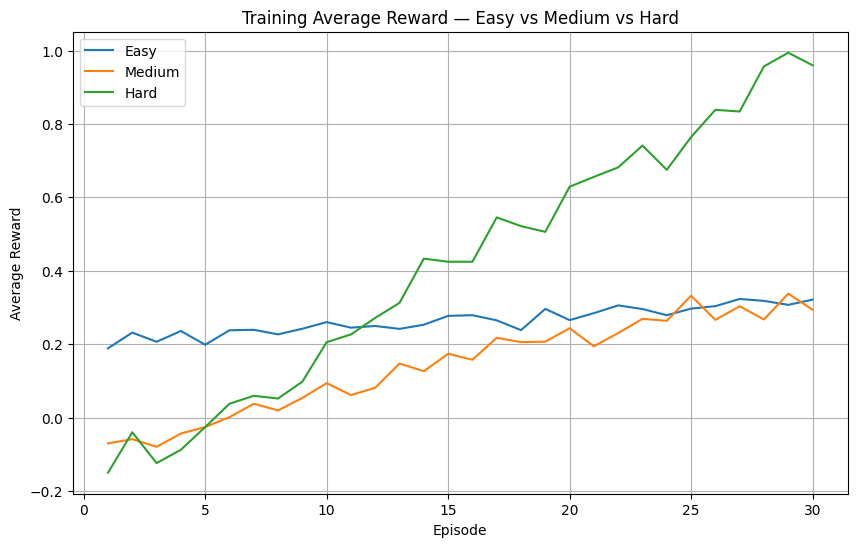

Graphique sauvegardé: C:\Users\UltraPc\Documents\ML PROBA\C-marl\results\training_average_rewards.png


In [14]:
plt.figure(figsize=(10, 6))
plt.plot(easy_history["episode"], easy_history["average_reward"], label="Easy")
plt.plot(medium_history["episode"], medium_history["average_reward"], label="Medium")
plt.plot(hard_history["episode"], hard_history["average_reward"], label="Hard")

plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Training Average Reward — Easy vs Medium vs Hard")
plt.legend()
plt.grid(True)

plot_path = os.path.join(RESULTS_DIR, "training_average_rewards.png")
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Graphique sauvegardé:", plot_path)

## Cellule 15 — Vérifier les fichiers créés

In [15]:
print("Fichiers dans checkpoints:")
for file in os.listdir(CHECKPOINT_DIR):
    print("-", file)

print("\nFichiers dans results:")
for file in os.listdir(RESULTS_DIR):
    if "reward" in file or "training" in file:
        print("-", file)

Fichiers dans checkpoints:
- checkpoint_easy.pkl
- checkpoint_hard.pkl
- checkpoint_medium.pkl

Fichiers dans results:
- rewards_easy.csv
- rewards_hard.csv
- rewards_medium.csv
- training_average_rewards.png


## Cellule 16 — Message final

À la fin de ce notebook, tu dois avoir :

- `checkpoint_easy.pkl`
- `checkpoint_medium.pkl`
- `checkpoint_hard.pkl`
- `rewards_easy.csv`
- `rewards_medium.csv`
- `rewards_hard.csv`
- `training_average_rewards.png`

Le Notebook 04 va utiliser ces fichiers pour faire l'évaluation finale.

In [16]:
print("Notebook 03 terminé avec succès.")
print("Les agents sont entraînés et les checkpoints sont sauvegardés.")
print("Prochaine étape : Notebook 04 — Evaluation & Results.")

Notebook 03 terminé avec succès.
Les agents sont entraînés et les checkpoints sont sauvegardés.
Prochaine étape : Notebook 04 — Evaluation & Results.
